<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [2]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [5]:
path = "../data/Wholesale customers data.csv"
df = pd.read_csv(path)



#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

In [10]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nFirst rows:")
display(df.head())

Shape: (440, 9)

Columns:
Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen', 'Total_Spending'],
      dtype='object')

First rows:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Total_Spending
0,2,3,12669,9656,7561,214,2674,1338,34112
1,2,3,7057,9810,9568,1762,3293,1776,33266
2,2,3,6353,8808,7684,2405,3516,7844,36610
3,1,3,13265,1196,4221,6404,507,1788,27381
4,2,3,22615,5410,7198,3915,1777,5185,46100


**Your observations here**

- ex.: Frozen, Grocery, Milk and Detergents Paper have a high...
- ...



1. Column Meaning

Channel: Customer type

1 = Horeca (Hotel/Restaurant/Café)

2 = Retail

Region: Geographic region

1 = Lisbon

2 = Oporto

3 = Other

Remaining columns: Annual spending (monetary units) on product categories:
For clustering, these are continuous numerical consumption variables.

2. EDA 

Descriptive statistics:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000



Channel distribution:
Channel
1    298
2    142
Name: count, dtype: int64

Region distribution:
Region
3    316
1     77
2     47
Name: count, dtype: int64


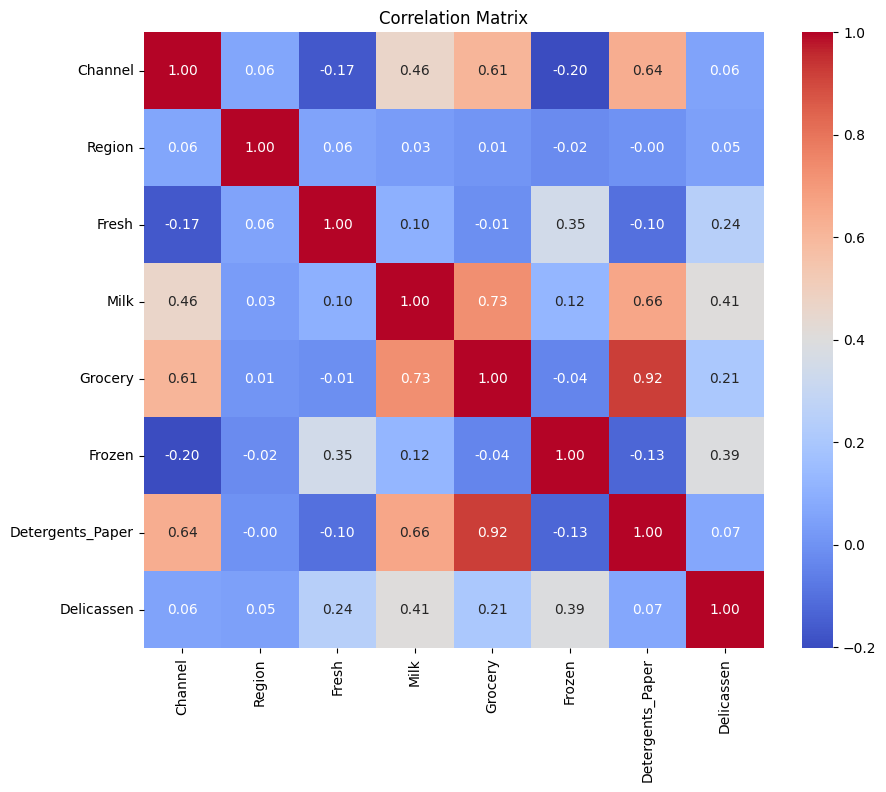

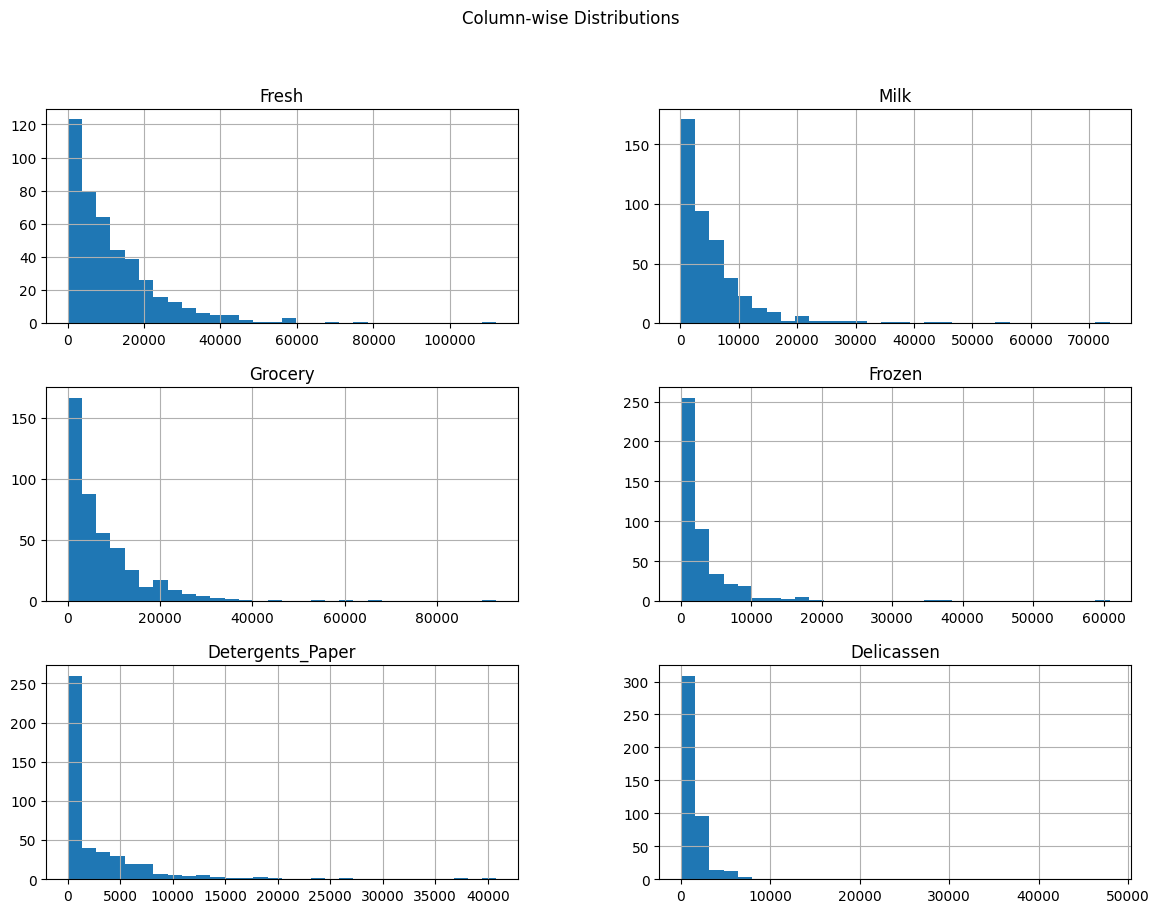

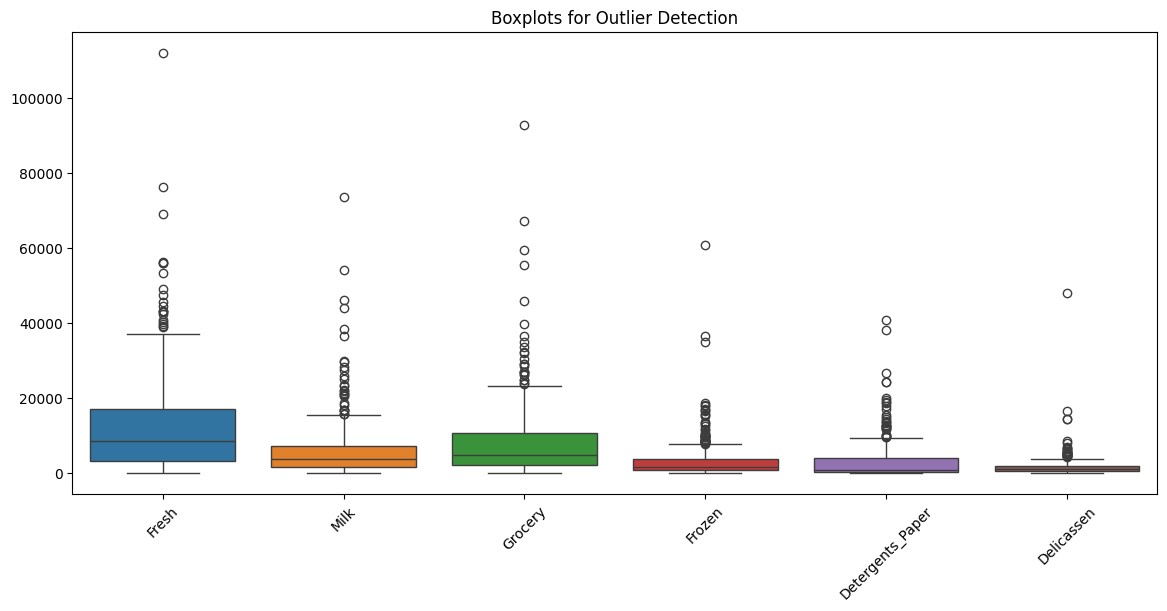

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Basic statistics
print("Descriptive statistics:")
display(df.describe())

# Check categorical distributions
print("\nChannel distribution:")
print(df["Channel"].value_counts())

print("\nRegion distribution:")
print(df["Region"].value_counts())

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Distribution plots
numerical_cols = df.columns.drop(["Channel", "Region"])

df[numerical_cols].hist(figsize=(14, 10), bins=30)
plt.suptitle("Column-wise Distributions")
plt.show()

# Boxplots for outlier detection
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.title("Boxplots for Outlier Detection")
plt.show()

In [7]:
print("\nNulls per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)


Nulls per column:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Data types:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object


Pareto Principle Analysis

Percentage of customers generating 80% of revenue: 57.05%


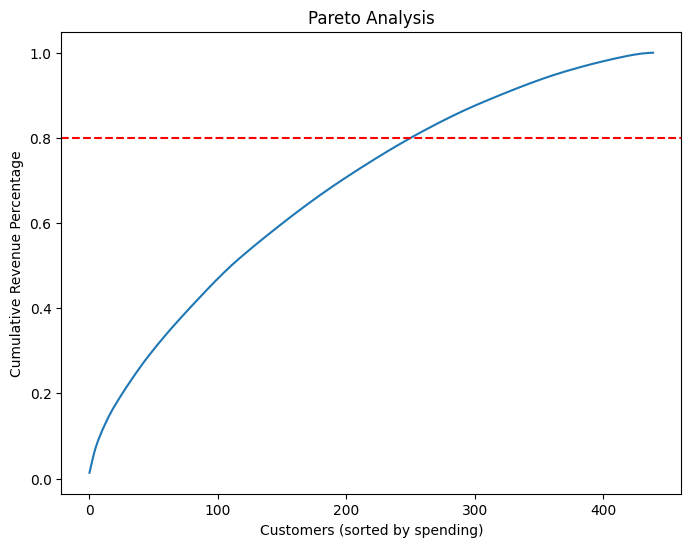

In [11]:
# we check if ~20% of customers generate ~80% of total spending.
# Compute total spending per customer
df["Total_Spending"] = df[numerical_cols].sum(axis=1)

# Sort descending
df_sorted = df.sort_values("Total_Spending", ascending=False)

# Compute cumulative percentage
df_sorted["Cumulative_Percentage"] = (
    df_sorted["Total_Spending"].cumsum() / df_sorted["Total_Spending"].sum()
)

# Find percentage of customers responsible for 80% of revenue
pareto_threshold = df_sorted[df_sorted["Cumulative_Percentage"] <= 0.8]
percentage_customers = len(pareto_threshold) / len(df_sorted) * 100

print(f"Percentage of customers generating 80% of revenue: {percentage_customers:.2f}%")

# Plot Pareto curve
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(df_sorted)), df_sorted["Cumulative_Percentage"])
plt.axhline(0.8, color="red", linestyle="--")
plt.title("Pareto Analysis")
plt.xlabel("Customers (sorted by spending)")
plt.ylabel("Cumulative Revenue Percentage")
plt.show()

No missing data.

Two categorical variables (Channel, Region).

Strong multicollinearity in detergent_paper, milk and groceries.

Severe right skewness across all spending columns.

Presence of high-value outliers (likely valid).

No pareto-like concentration (57% of customers - 80% of expense).

PCA + log transformation strongly recommended before KMeans.

# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

The dataset required transformation because:

It contains severe positive skew.

It has large scale differences.

It contains high-magnitude outliers.

It will be used in distance-based clustering.

Separate Features

In [12]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Drop categorical and engineered columns
features = df.drop(columns=["Channel", "Region", "Total_Spending"])

print("Feature shape:", features.shape)

Feature shape: (440, 6)


Log Transformation

In [13]:
# Apply log(1 + x) to reduce skewness
features_log = np.log1p(features)

print("Skewness after log transform:")
print(features_log.skew())

Skewness after log transform:
Fresh              -1.575326
Milk               -0.224063
Grocery            -0.674938
Frozen             -0.352655
Detergents_Paper   -0.235961
Delicassen         -1.091827
dtype: float64


Standard Scaling

In [14]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_log)

print("Mean after scaling (approx 0):")
print(features_scaled.mean(axis=0))

print("Std after scaling (approx 1):")
print(features_scaled.std(axis=0))

Mean after scaling (approx 0):
[ 3.22973971e-17 -7.10542736e-16 -1.08196280e-15  2.98750923e-16
 -6.29799243e-16 -2.22044605e-17]
Std after scaling (approx 1):
[1. 1. 1. 1. 1. 1.]


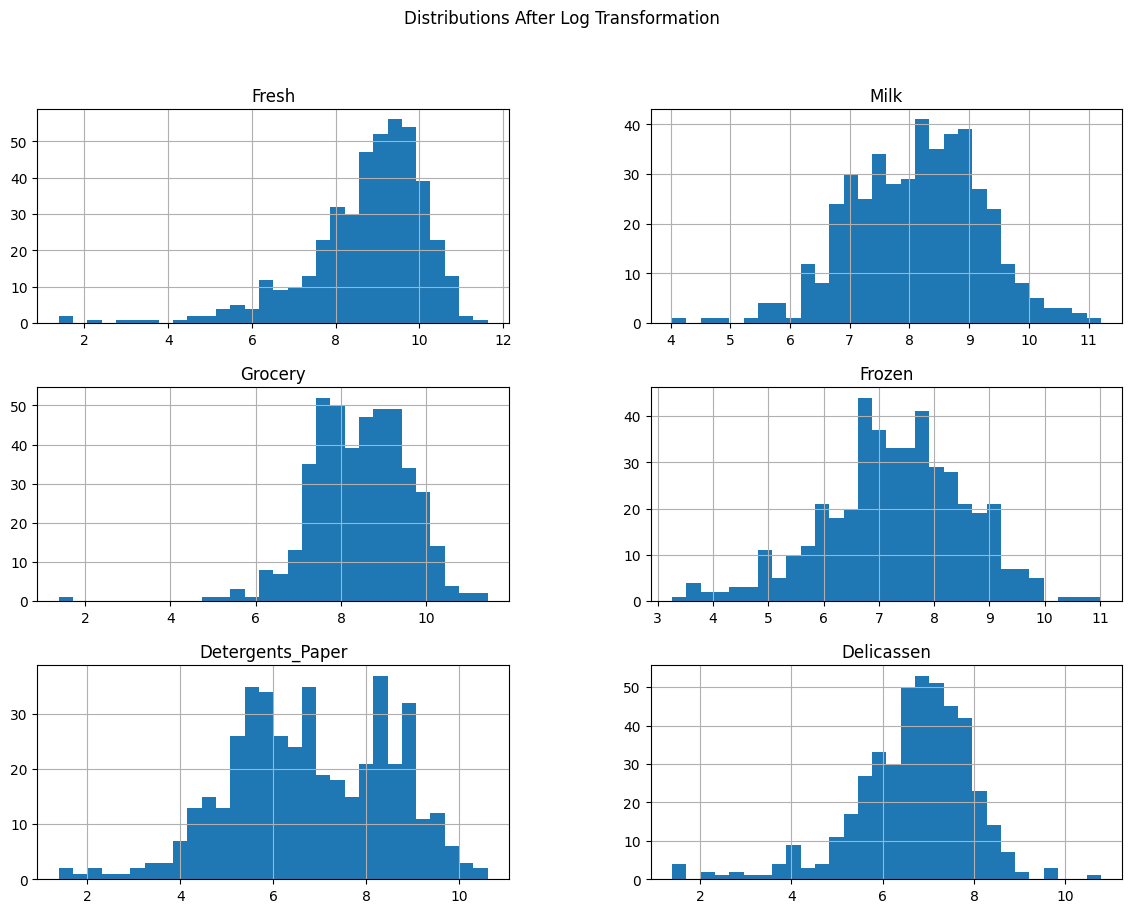

In [15]:


features_log_df = pd.DataFrame(features_log, columns=features.columns)

features_log_df.hist(figsize=(14,10), bins=30)
plt.suptitle("Distributions After Log Transformation")
plt.show()

# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [17]:
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import StandardScaler

# Select only numerical spending features
features = df.drop(columns=["Channel", "Region", "Total_Spending"])

# Initialize scaler
scaler = StandardScaler()

# Fit and transform
customers_scale = scaler.fit_transform(features)

print("Scaled data shape:", customers_scale.shape)

print("Means after scaling (approx 0):")
print(customers_scale.mean(axis=0))

print("\nStandard deviations after scaling (approx 1):")
print(customers_scale.std(axis=0))


Scaled data shape: (440, 6)
Means after scaling (approx 0):
[-3.43159844e-17  0.00000000e+00 -4.03717464e-17  3.63345717e-17
  2.42230478e-17 -8.07434927e-18]

Standard deviations after scaling (approx 1):
[1. 1. 1. 1. 1. 1.]


# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

In [18]:
from sklearn.cluster import KMeans

# Define number of clusters
k = 3

# Initialize model
kmeans = KMeans(n_clusters=k, random_state=42)

# Fit model
kmeans.fit(customers_scale)

# Extract cluster labels
labels = kmeans.labels_

# Add labels to original dataframe
df["labels"] = labels

print("Cluster counts:")
print(df["labels"].value_counts())

print("\nFirst rows with cluster labels:")
display(df.head())

Cluster counts:
labels
0    350
1     53
2     37
Name: count, dtype: int64

First rows with cluster labels:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Total_Spending,labels
0,2,3,12669,9656,7561,214,2674,1338,34112,0
1,2,3,7057,9810,9568,1762,3293,1776,33266,0
2,2,3,6353,8808,7684,2405,3516,7844,36610,0
3,1,3,13265,1196,4221,6404,507,1788,27381,0
4,2,3,22615,5410,7198,3915,1777,5185,46100,1


In [19]:
cluster_summary = df.groupby("labels").mean()
display(cluster_summary)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Total_Spending
labels,,,,,,,,,
0,1.282857,2.534286,8935.500000,4228.528571,5848.034286,2167.231429,1913.605714,1102.120000,24195.020000
1,1.113208,2.698113,34540.113208,5860.358491,6122.622642,9841.735849,981.471698,3664.245283,61010.547170
2,2.000000,2.405405,8704.864865,20534.405405,30466.243243,1932.621622,14758.837838,2459.351351,78856.324324


### Looking to the elbow we can choose 2 like the correct number of clusters

In [22]:
kmeans_2 = KMeans(n_clusters=2).fit(customers_scale)

labels = kmeans_2.predict(customers_scale)

clusters = kmeans_2.labels_.tolist()

In [24]:
df['Label'] = clusters

Count the values in `labels`.

In [25]:
print("Cluster distribution:")
print(df["Label"].value_counts())

Cluster distribution:
Label
0    395
1     45
Name: count, dtype: int64


# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [28]:
from sklearn.cluster import DBSCAN

# Initialize DBSCAN
dbscan = DBSCAN(eps=0.5)

# Fit model
dbscan.fit(customers_scale)

# Extract labels
df["labels_DBSCAN"] = dbscan.labels_




Count the values in `labels_DBSCAN`.

In [29]:
print("DBSCAN cluster distribution:")
print(df["labels_DBSCAN"].value_counts())

DBSCAN cluster distribution:
labels_DBSCAN
 0    261
-1    174
 1      5
Name: count, dtype: int64


# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [30]:
def plot(x,y,hue):
    sns.scatterplot(x=x, 
                    y=y,
                    hue=hue)
    plt.title('Detergents Paper vs Milk ')
    return plt.show();

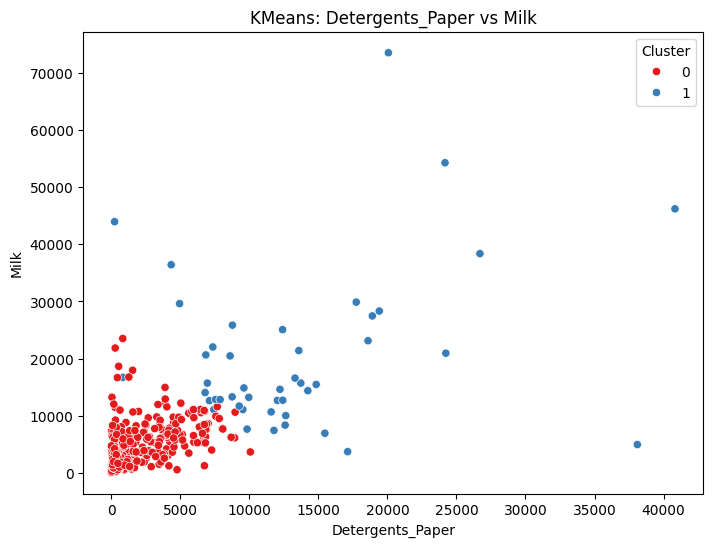

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Detergents_Paper"],
    y=df["Milk"],
    hue=df["Label"],
    palette="Set1"
)

plt.title("KMeans: Detergents_Paper vs Milk")
plt.xlabel("Detergents_Paper")
plt.ylabel("Milk")
plt.legend(title="Cluster")
plt.show()

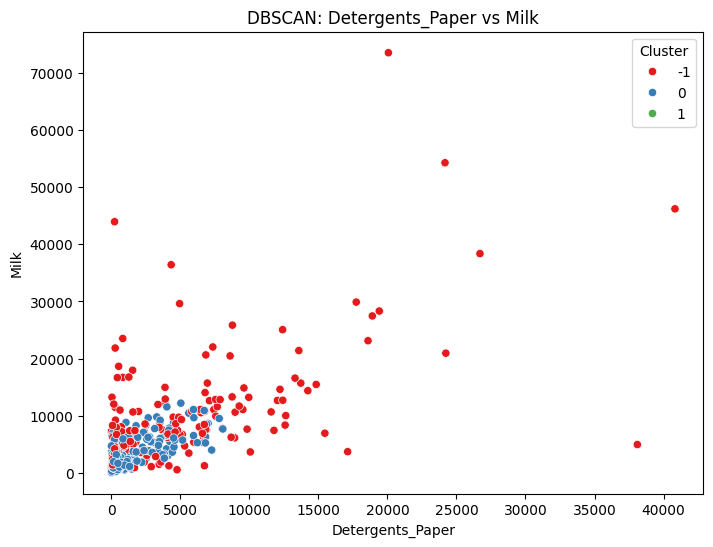

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Detergents_Paper"],
    y=df["Milk"],
    hue=df["labels_DBSCAN"],
    palette="Set1"
)

plt.title("DBSCAN: Detergents_Paper vs Milk")
plt.xlabel("Detergents_Paper")
plt.ylabel("Milk")
plt.legend(title="Cluster")
plt.show()

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

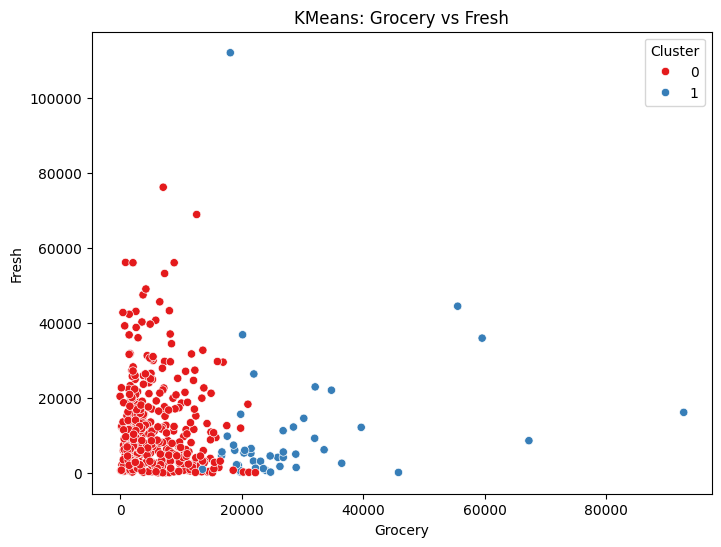

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Grocery"],
    y=df["Fresh"],
    hue=df["Label"],
    palette="Set1"
)

plt.title("KMeans: Grocery vs Fresh")
plt.xlabel("Grocery")
plt.ylabel("Fresh")
plt.legend(title="Cluster")
plt.show()

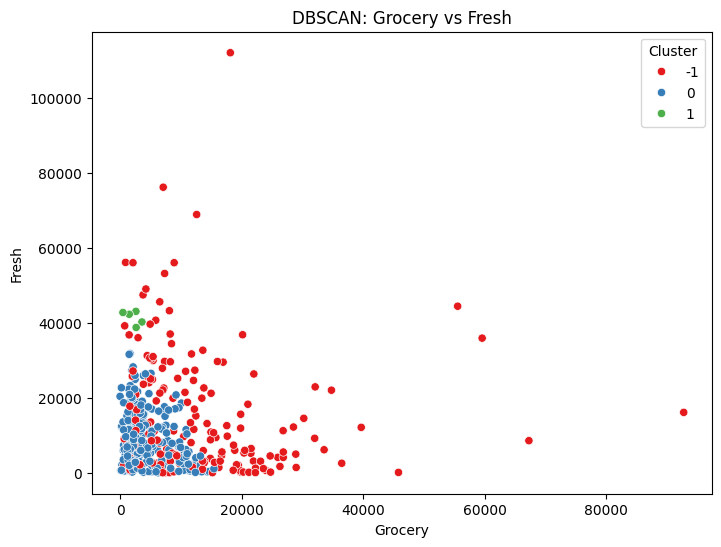

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Grocery"],
    y=df["Fresh"],
    hue=df["labels_DBSCAN"],
    palette="Set1"
)

plt.title("DBSCAN: Grocery vs Fresh")
plt.xlabel("Grocery")
plt.ylabel("Fresh")
plt.legend(title="Cluster")
plt.show()


Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

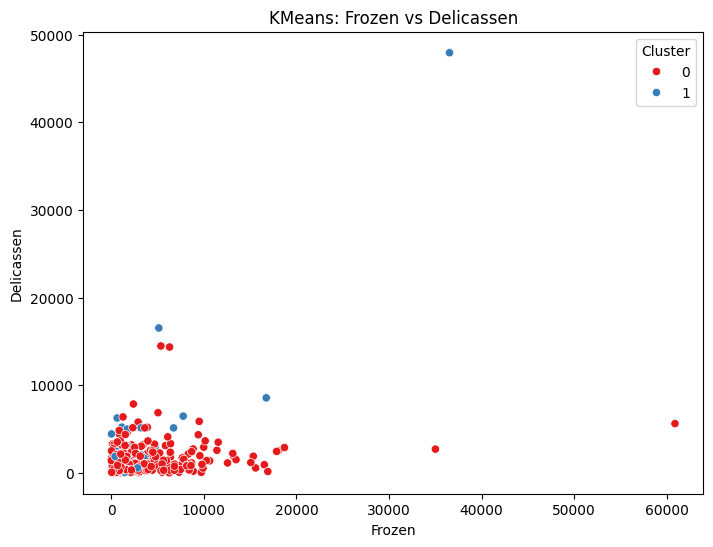

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Frozen"],
    y=df["Delicassen"],
    hue=df["Label"],
    palette="Set1"
)

plt.title("KMeans: Frozen vs Delicassen")
plt.xlabel("Frozen")
plt.ylabel("Delicassen")
plt.legend(title="Cluster")
plt.show()

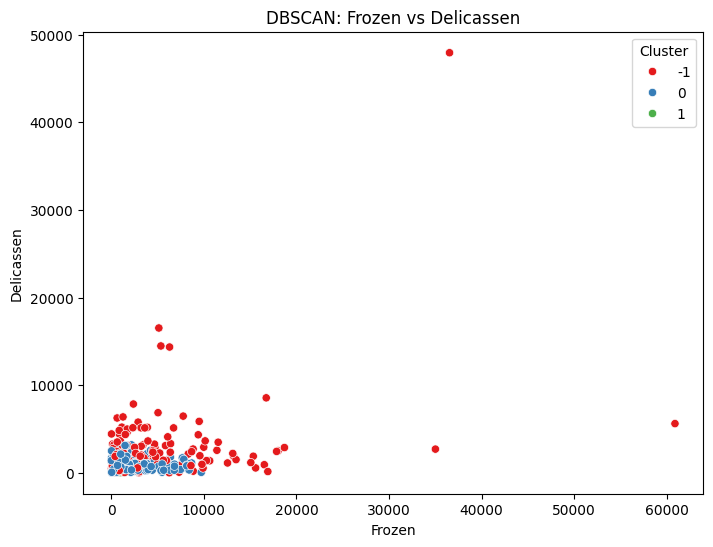

In [39]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Frozen"],
    y=df["Delicassen"],
    hue=df["labels_DBSCAN"],
    palette="Set1"
)

plt.title("DBSCAN: Frozen vs Delicassen")
plt.xlabel("Frozen")
plt.ylabel("Delicassen")
plt.legend(title="Cluster")
plt.show()

Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [43]:
# Group by KMeans labels and compute mean of all numerical columns
kmeans_group_means = df.groupby("Label").mean()

print("Mean values by KMeans cluster:")
display(kmeans_group_means)

# group by dbscan labels
dbscan_group_means = df.groupby("labels_DBSCAN").mean()

print("Mean values by DBSCAN cluster (including noise):")
display(dbscan_group_means)

dbscan_no_noise = df[df["labels_DBSCAN"] != -1]

dbscan_group_means_no_noise = dbscan_no_noise.groupby("labels_DBSCAN").mean()

print("Mean values by DBSCAN cluster (excluding noise):")
display(dbscan_group_means_no_noise)

Mean values by KMeans cluster:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Total_Spending,labels,labels_DBSCAN
Label,,,,,,,,,,,
0,1.250633,2.546835,12084.959494,4152.612658,5595.116456,3080.463291,1712.782278,1309.549367,27935.483544,0.129114,-0.313924
1,1.955556,2.511111,11257.155556,20223.888889,28633.133333,2997.044444,13140.177778,3414.911111,79666.311111,1.688889,-1.000000


Mean values by DBSCAN cluster (including noise):


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Total_Spending,labels,Label
labels_DBSCAN,,,,,,,,,,,
-1,1.522989,2.551724,15608.988506,10000.408046,13693.298851,4786.275862,5291.373563,2510.781609,51891.126437,0.695402,0.258621
0,1.195402,2.528736,9030.398467,3077.318008,4234.061303,1963.432950,1322.134100,881.773946,20509.118774,0.003831,0.000000
1,1.000000,3.000000,41446.600000,1421.200000,2167.600000,1276.400000,416.200000,784.800000,47512.800000,1.000000,0.000000


Mean values by DBSCAN cluster (excluding noise):


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Total_Spending,labels,Label
labels_DBSCAN,,,,,,,,,,,
0,1.195402,2.528736,9030.398467,3077.318008,4234.061303,1963.43295,1322.1341,881.773946,20509.118774,0.003831,0.0
1,1.000000,3.000000,41446.600000,1421.200000,2167.600000,1276.40000,416.2000,784.800000,47512.800000,1.000000,0.0


Which algorithm appears to perform better?

KMeans appears to perform better for this dataset.

Reasons:

KMeans produces two well-separated, economically interpretable segments.

The clusters show clear differences in spending behavior.

DBSCAN classifies a large portion of customers as noise.

# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

In [41]:
# Your code here:

**Your comment here**

- 

# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

In [ ]:
# Your code here

**Your comment here**

- 